# Week 7 Lab: Fine-Tuning Under Real Compute Constraints

In previous weeks we focused on how transformer models work.  
In this lab we focus on **model adaptation**: taking a pretrained model and adapting it to a specific classification task.

Our main question is:

**When is full fine-tuning worth it, and when is a cheaper baseline already good enough?**

By the end of this notebook, we should be able to:

- explain why transfer learning is usually preferred over training from scratch,
- build a frozen-backbone baseline for text classification,
- fine-tune the full model using Hugging Face `Trainer`,
- compare both approaches using consistent metrics,
- inspect errors and make an evidence-based judgement about whether full fine-tuning was worthwhile.

## Why this matters

A pretrained model may look impressive in a demo but still perform poorly on your actual task.

Fine-tuning helps adapt a general language model to:

- your label space,
- your dataset,
- your decision boundary.

However, full fine-tuning costs more compute and adds more optimisation complexity.

So in this notebook we do **not** jump straight to full fine-tuning.

Instead, we follow this workflow:

`dataset -> tokenization -> frozen-head baseline -> full fine-tune -> evaluation -> error analysis -> decision`

The goal is not just to train a model.  
The goal is to decide whether the extra training cost is justified by the evidence.

## 1. Setup



### Core imports

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from huggingface_hub import HfApi
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments,Trainer

import os
from dotenv import load_dotenv
load_dotenv()
HF_TOKEN = os.getenv("HUGGINGFACE_API_KEY")

if not HF_TOKEN:
    raise ValueError(
       "HUGGINGFACE_API_KEY not found.\n"
        "→ Copy .env.example to .env\n"
        "→ Add your HuggingFace API key"
    )


### Reproducibility defaults

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
sns.set_theme(style='whitegrid')

### Setup Google Drive

In [3]:
import os


base_path = os.getcwd()

os.chdir(base_path)

print(os.getcwd())

/Users/jacktovey/Library/CloudStorage/OneDrive-UniversityofChichester/COM407-AppliedAI/week_7


### Why these imports?

- `datasets` we are farmilia with and will use this to load and slices the task data.
- `transformers` and `Trainer` handle both the frozen-head baseline and the full fine-tuning workflow..
- `sklearn.metrics` gives us readable reports and confusion matrices.

### Quick reference: defaults for this notebook

| setting                       | value                                      | reason                                                            |
|:------------------------------|:-------------------------------------------|:------------------------------------------------------------------|
| checkpoint                    | bert-base-uncased                          | same encoder for the frozen baseline and the full fine-tuning run |
| baseline strategy             | frozen encoder + train classification head | modern evidence floor without changing model family               |
| frozen baseline learning_rate | 0.0005                                     | only a small head is trainable                                    |
| full fine-tune learning_rate  | 2e-05                                      | conservative default when all weights can move                    |
| frozen baseline epochs        | 2                                          | cheap enough to give the head a fair chance                       |
| full fine-tune epochs         | 1                                          | runtime control and reduced overfitting risk                      |
| train_batch_size              | 16                                         | modest GPU memory use                                             |
| eval_batch_size               | 32                                         | faster evaluation on the same runtime                             |

## 2. Load and inspect dataset

We will carry on from last week and use `rotten_tomatoes` because it is quick to load, and easy to interpret.

In [4]:
raw = load_dataset('rotten_tomatoes')
raw

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

### Inspect columns and label schema

In [5]:
print('Train columns:', raw['train'].column_names)
print('Features:', raw['train'].features)
print('Label names:', raw['train'].features['label'].names)

Train columns: ['text', 'label']
Features: {'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}
Label names: ['neg', 'pos']


### Peek at examples

We've seen this data before but let's check a few examples.

In [6]:
pd.DataFrame(raw['train'][:3])

,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1


### Class balance check

It is useful to check the distribution of the class labels to see how balanced the samples are.

In [7]:
train_df = raw['train'].to_pandas()
train_df['label'].value_counts().sort_index()

label
0    4265
1    4265
Name: count, dtype: int64

### Why this matters

If we do not understand the label space and the split sizes, then both the baseline and the fine-tuned result can be misleading.

### Train/Val/Test

In [8]:
train = raw['train']
valid = raw['validation']
test = raw['test']

## 3. Baseline choice: frozen backbone + classifier head

First, we use the pretrained transformer as a fixed feature extractor and train only the task head on top.

### Why this baseline is reasonable

- It keeps the checkpoint, tokenizer, and label space aligned with the later full fine-tuning run.
- It shows what the pretrained representation can do before we let the encoder move.
- It is effectively a fixed-embedding baseline plus a simple neural head, but inside the same Hugging Face workflow.

### Why we are not using an already fine-tuned sentiment classifier

An off-the-shelf sentiment model would mix in someone else's task adaptation, label choices, and hidden training history. That makes the comparison less controlled and we would need to be careful that there was no data leakage.

## 4. Tokenization and model-ready inputs

Now we turn raw text into the shared transformer inputs used by both the frozen-head baseline and the fully fine-tuned model.

### Select checkpoint

In [9]:
checkpoint = 'bert-base-uncased'

### Optional reproducibility helper: pin a revision SHA

In [10]:
hf_api = HfApi()
try:
    checkpoint_sha = hf_api.model_info(checkpoint).sha
except Exception:
    checkpoint_sha = 'main'

print('checkpoint:', checkpoint)
print('revision:', checkpoint_sha)

checkpoint: bert-base-uncased
revision: 86b5e0934494bd15c9632b12f734a8a67f723594


### Check for Satetensors

In [11]:
SAFETENSOR_FILES = (
    "model.safetensors",
    "model.safetensors.index.json",  # sharded models
)

def has_safetensors(api, model_id, revision):
    return any(
        api.file_exists(model_id, filename, revision=revision)
        for filename in SAFETENSOR_FILES
    )

has_safetensors(hf_api, checkpoint, checkpoint_sha)



True

### Load tokenizer

In [12]:
tokenizer = AutoTokenizer.from_pretrained(
    checkpoint,
    revision=checkpoint_sha,
    trust_remote_code=False,
)

### Tokenization Example

In [13]:
demo_texts = train['text'][:2]
demo_batch = tokenizer(demo_texts, truncation=True)

# print(demo_batch)

pd.DataFrame({
    'text': demo_texts,
    'token_count': [len(ids) for ids in demo_batch['input_ids']],
})

,text,token_count
0,the rock is destined to be the 21st century's ...,47
1,"the gorgeously elaborate continuation of "" the...",52


### Inspect tokens and the attention mask for one example

In [14]:
demo_tokens = tokenizer.convert_ids_to_tokens(demo_batch['input_ids'][0])

pd.DataFrame({
    'token': demo_tokens[:10],
    'attention_mask': demo_batch['attention_mask'][0][:10],
})

,token,attention_mask
0,[CLS],1
1,the,1
2,rock,1
3,is,1
4,destined,1
5,to,1
6,be,1
7,the,1
8,21st,1
9,century,1


### Inspect tokenized example

In [15]:
demo_texts = train["text"][:2]
demo_batch = tokenizer(demo_texts, truncation=False)

pd.DataFrame({
    "text": demo_texts,
    "token_count": [len(ids) for ids in demo_batch["input_ids"]],
})

,text,token_count
0,the rock is destined to be the 21st century's ...,47
1,"the gorgeously elaborate continuation of "" the...",52


### Sequence length distribution

In [16]:
def get_length(example):
    tokens = tokenizer(example["text"], truncation=False)
    return {"length": len(tokens["input_ids"])}

length_train = train.map(get_length)
lengths_df = pd.DataFrame({"length": length_train["length"]})
lengths_df.describe()

,length
count,8530.000000
mean,27.368347
std,11.269020
min,3.000000
25%,19.000000
50%,27.000000
75%,35.000000
max,78.000000


### Sequence length histogram

The histogram helps us judge whether a shorter max length would save compute with limited information loss.
        

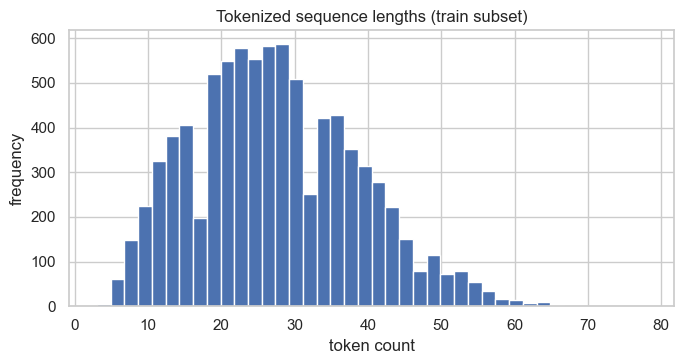

In [17]:
lengths = length_train["length"]

plt.figure(figsize=(7, 3.8))
plt.hist(lengths, bins=40, edgecolor='white')
plt.title('Tokenized sequence lengths (train subset)')
plt.xlabel('token count')
plt.ylabel('frequency')
plt.tight_layout()
plt.show()

### Task

Compute the proportion of training samples that are longer than 128 tokens. Explain what this implies for truncation choices.

### Solution

In [18]:
prop_over_128 = float((lengths_df['length'] > 128).mean())
print('Proportion over 128 tokens:', round(prop_over_128, 4))

Proportion over 128 tokens: 0.0


The trucation will not effect the training data.

### Define Tokeniser

In [19]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

### Apply Tokeniser

In [20]:
tokenized_train = train.map(tokenize_batch, batched=True)
tokenized_valid = valid.map(tokenize_batch, batched=True)
tokenized_test = test.map(tokenize_batch, batched=True)

#### Inspect Example

In [21]:
example = tokenized_train[0]

{
    "text": example["text"],
    "label": example["label"],
    "input_ids_first_12": example["input_ids"][:12],
    "attention_mask_first_12": example["attention_mask"][:12],
    "stored_length": len(example["input_ids"]),
}

{'text': 'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .',
 'label': 1,
 'input_ids_first_12': [101,
  1996,
  2600,
  2003,
  16036,
  2000,
  2022,
  1996,
  7398,
  2301,
  1005,
  1055],
 'attention_mask_first_12': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'stored_length': 47}

#### Convert example back to tokens

In [22]:
tokens_example = tokenizer.convert_ids_to_tokens(example["input_ids"])

pd.DataFrame({
    "token": tokens_example[:20],
    "input_id": example["input_ids"][:20],
    "attention_mask": example["attention_mask"][:20],
})

,token,input_id,attention_mask
0,[CLS],101,1
1,the,1996,1
2,rock,2600,1
3,is,2003,1
4,destined,16036,1
5,to,2000,1
6,be,2022,1
7,the,1996,1
8,21st,7398,1
9,century,2301,1


### 4.5 Padding: fixed length vs dynamic padding

Tokenized examples in a batch do not all have the same length.
To stack them into tensors, we need padding.

There are two common choices:

- fixed-length padding: pad every sequence to the same global length, such as 128
- dynamic padding: pad only to the longest sequence in the current batch

For training, dynamic padding is often more efficient.


####  Dynamic padding via a data collator

In [23]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

#### Compare fixed vs Dynamic

In [24]:
sample_texts = train["text"][:2]

fixed_batch = tokenizer(
    sample_texts,
    truncation=True,
    padding="max_length",
    max_length=128,
)

dynamic_batch = tokenizer(
    sample_texts,
    truncation=True,
    padding=True,
)

pd.DataFrame([
    {
        "padding_mode": f"max_length={128}",
        "true_lengths": [sum(mask) for mask in fixed_batch["attention_mask"]],
        "stored_length": len(fixed_batch["input_ids"][0]),
    },
    {
        "padding_mode": "batch local",
        "true_lengths": [sum(mask) for mask in dynamic_batch["attention_mask"]],
        "stored_length": len(dynamic_batch["input_ids"][0]),
    },
])

,padding_mode,true_lengths,stored_length
0,max_length=128,"[47, 52]",128
1,batch local,"[47, 52]",52


#### Why dynamic padding matters

If we always pad to a global maximum, we may waste a lot of computation on padding tokens.

Dynamic padding is more efficient because each batch is padded only up to the longest sequence in that batch.

That is especially helpful when sequence lengths vary a lot.

### Set up explicit columns for `Trainer`

In [25]:
tokenized_train = tokenized_train.rename_column('label', 'labels')
tokenized_valid = tokenized_valid.rename_column('label', 'labels')
tokenized_test = tokenized_test.rename_column('label', 'labels')

columns_for_trainer = ['input_ids', 'attention_mask', 'labels']
for dataset in (tokenized_train, tokenized_valid, tokenized_test):
    dataset.set_format(type='torch', columns=columns_for_trainer)

tokenized_train[0]

{'labels': tensor(1),
 'input_ids': tensor([  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
          1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
          1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
         29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
          4168,  2030,  7112, 16562,  2140,  1012,   102]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}

## 5. Frozen-backbone baseline and metrics

We keep the backbone fixed and train only the classifier head. This gives us a modern evidence floor before full fine-tuning.

### Make label mapping explicit

This keeps the dataset, model config, and evaluation outputs aligned.
        

In [26]:
label_names = raw['train'].features['label'].names
id2label = {idx: name for idx, name in enumerate(label_names)}
label2id = {name: idx for idx, name in id2label.items()}
num_labels = len(label_names)

pd.DataFrame({
    'label_id': list(id2label.keys()),
    'label_name': list(id2label.values()),
})

,label_id,label_name
0,0,neg
1,1,pos


### Metric setup

In [27]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

def parameter_summary(model):
    total = sum(param.numel() for param in model.parameters())
    trainable = sum(param.numel() for param in model.parameters() if param.requires_grad)
    return {
        'trainable_params': f'{trainable:,}',
        'total_params': f'{total:,}',
        'trainable_fraction': round(trainable / total, 6),
    }

### Load the frozen-head baseline model

We reuse the pretrained checkpoint and attach the task head, but we do not let the encoder weights move.

In [28]:
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    revision=checkpoint_sha,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    trust_remote_code=False,
    use_safetensors=True,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Freeze the encoder weights

This is the fixed-representation step: only the small classification head remains trainable.

In [29]:
for param in baseline_model.base_model.parameters():
    param.requires_grad = False

### Quick sanity check

In [30]:
trainable_parameter_names = [name for name, param in baseline_model.named_parameters() if param.requires_grad]
baseline_summary = {
    'parameter_summary': parameter_summary(baseline_model),
    'trainable_tensors': trainable_parameter_names,
}

baseline_summary

{'parameter_summary': {'trainable_params': '1,538',
  'total_params': '109,483,778',
  'trainable_fraction': 1.4e-05},
 'trainable_tensors': ['classifier.weight', 'classifier.bias']}

### Training arguments

In [31]:
baseline_training_args = TrainingArguments(
    output_dir='assets/baseline',
    learning_rate=5e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_steps=50,
    seed=SEED,
    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    greater_is_better=True,
)

### Build baseline trainer

In [32]:
baseline_trainer = Trainer(
    model=baseline_model,
    args=baseline_training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

### Run baseline training

In [33]:
baseline_train_result = baseline_trainer.train()
baseline_train_result

/Users/jacktovey/Library/CloudStorage/OneDrive-UniversityofChichester/COM407-AppliedAI/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.630398,0.627943,0.590056,0.526331
2,0.602527,0.566025,0.730769,0.729636
3,0.583776,0.556200,0.729831,0.726364
4,0.589830,0.541407,0.757036,0.756988
5,0.569672,0.538956,0.759850,0.759796


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jacktovey/Library/CloudStorage/OneDrive-UniversityofChichester/COM407-AppliedAI/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jacktovey/Library/CloudStorage/OneDrive-UniversityofChichester/COM407-AppliedAI/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2670, training_loss=0.5989400320731745, metrics={'train_runtime': 425.6684, 'train_samples_per_second': 100.195, 'train_steps_per_second': 6.272, 'total_flos': 1069254551211360.0, 'train_loss': 0.5989400320731745, 'epoch': 5.0})

### Evaluate on validation and test splits

In [34]:
baseline_valid_pred_out = baseline_trainer.predict(tokenized_valid)
baseline_valid_pred_ids = np.argmax(baseline_valid_pred_out.predictions, axis=-1)

baseline_test_pred_out = baseline_trainer.predict(tokenized_test)
baseline_test_pred_ids = np.argmax(baseline_test_pred_out.predictions, axis=-1)

baseline_valid_acc = accuracy_score(valid["label"], baseline_valid_pred_ids)
baseline_valid_f1 = f1_score(valid["label"], baseline_valid_pred_ids, average="macro")

baseline_test_acc = accuracy_score(test["label"], baseline_test_pred_ids)
baseline_test_f1 = f1_score(test["label"], baseline_test_pred_ids, average="macro")

baseline_valid_acc

/Users/jacktovey/Library/CloudStorage/OneDrive-UniversityofChichester/COM407-AppliedAI/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


/Users/jacktovey/Library/CloudStorage/OneDrive-UniversityofChichester/COM407-AppliedAI/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


0.7598499061913696

### Classification report (baseline)

Read this alongside accuracy and macro F1 so we can see per-class behavior, not just the headline score.
        

In [35]:
print(classification_report(valid["label"], baseline_valid_pred_ids, target_names=label_names))

              precision    recall  f1-score   support

         neg       0.77      0.74      0.76       533
         pos       0.75      0.77      0.76       533

    accuracy                           0.76      1066
   macro avg       0.76      0.76      0.76      1066
weighted avg       0.76      0.76      0.76      1066



### Confusion matrix (baseline)

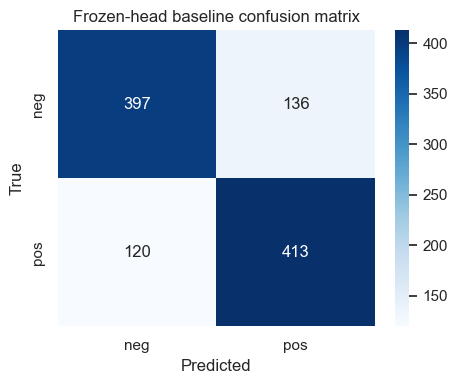

In [36]:
baseline_cm = confusion_matrix(valid["label"], baseline_valid_pred_ids)

plt.figure(figsize=(4.8, 4))
sns.heatmap(
    baseline_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.title('Frozen-head baseline confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

### Prediction DataFrame for Validation Data

In [37]:
baseline_df = pd.DataFrame({
    "text": valid["text"],
    "label": valid["label"],
    "baseline_pred": baseline_valid_pred_ids,
})

baseline_df.head()

,text,label,baseline_pred
0,compassionately explores the seemingly irrecon...,1,1
1,the soundtrack alone is worth the price of adm...,1,1
2,rodriguez does a splendid job of racial profil...,1,1
3,beneath the film's obvious determination to sh...,1,1
4,bielinsky is a filmmaker of impressive talent .,1,1


### Inspect a few baseline predictions on Validation Data

In [38]:
baseline_df['correct'] = baseline_df['label'] == baseline_df['baseline_pred']
baseline_df.head(8)

,text,label,baseline_pred,correct
0,compassionately explores the seemingly irrecon...,1,1,True
1,the soundtrack alone is worth the price of adm...,1,1,True
2,rodriguez does a splendid job of racial profil...,1,1,True
3,beneath the film's obvious determination to sh...,1,1,True
4,bielinsky is a filmmaker of impressive talent .,1,1,True
5,"so beautifully acted and directed , it's clear...",1,1,True
6,a visual spectacle full of stunning images and...,1,1,True
7,a gentle and engrossing character study .,1,1,True


### Look at baseline errors before full fine-tuning

In [39]:
baseline_errors_df = baseline_df[~baseline_df['correct']][['text', 'label', 'baseline_pred']].head(10)
baseline_errors_df

,text,label,baseline_pred
24,"it's more enjoyable than i expected , though ,...",1,0
26,those moviegoers who would automatically bypas...,1,0
27,baby-faced renner is eerily convincing as this...,1,0
37,the best comedy concert movie i've seen since ...,1,0
51,there's much tongue in cheek in the film and t...,1,0
52,"there's absolutely no reason why blue crush , ...",1,0
59,the events of the film are just so weird that ...,1,0
70,"as a science fiction movie , "" minority report...",1,0
78,adam sandler ! in an art film !,1,0
79,"as averse as i usually am to feel-good , follo...",1,0


### Checkpoint reflection

Before moving on, ask: what did head-only training already capture, and what signs suggest the encoder itself now needs to adapt?

## 6. Full fine-tuning with the same checkpoint

Now we unfreeze the whole checkpoint. This is the extra flexibility that full fine-tuning buys us, and it is what the frozen-head baseline has to justify.

### Load a fresh model for full fine-tuning

We start from the same pretrained checkpoint again so the only big difference is which weights are allowed to move.

In [40]:
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    revision=checkpoint_sha,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    trust_remote_code=False,
    use_safetensors=True,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Quick sanity check

In [41]:
full_tune_summary = parameter_summary(model)
full_tune_summary

{'trainable_params': '109,483,778',
 'total_params': '109,483,778',
 'trainable_fraction': 1.0}

### Training arguments

In [42]:
training_args = TrainingArguments(
    output_dir='assets/full_tune',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_steps=50,
    seed=SEED,
    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    greater_is_better=True,
)

### Build trainer

In [43]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

### Run training

In [44]:
train_result = trainer.train()
train_result

/Users/jacktovey/Library/CloudStorage/OneDrive-UniversityofChichester/COM407-AppliedAI/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.310077,0.349358,0.853659,0.853224
2,0.213205,0.401599,0.861163,0.861104


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jacktovey/Library/CloudStorage/OneDrive-UniversityofChichester/COM407-AppliedAI/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1068, training_loss=0.30349316422858935, metrics={'train_runtime': 614.4942, 'train_samples_per_second': 27.763, 'train_steps_per_second': 1.738, 'total_flos': 428305742578800.0, 'train_loss': 0.30349316422858935, 'epoch': 2.0})

### Inspect log history

In [45]:
log_history_df = pd.DataFrame(trainer.state.log_history)
log_history_df.tail(10)

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_macro_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
14,0.224592,2.734258,6.910112e-06,1.310861,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,0.200878,6.303458,5.973783e-06,1.404494,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,0.197710,17.665007,5.037453e-06,1.498127,800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,0.223788,9.967468,4.101124e-06,1.591760,850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,0.238837,13.583296,3.164794e-06,1.685393,900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,0.211614,3.237562,2.228464e-06,1.779026,950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,0.191717,0.909955,1.292135e-06,1.872659,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,0.213205,5.288653,3.558052e-07,1.966292,1050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,NaN,NaN,NaN,2.000000,1068,0.401599,0.861163,0.861104,11.6612,91.414,2.916,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,2.000000,1068,NaN,NaN,NaN,NaN,NaN,NaN,614.4942,27.763,1.738,4.283057e+14,0.303493


### Visualising training/validation loss

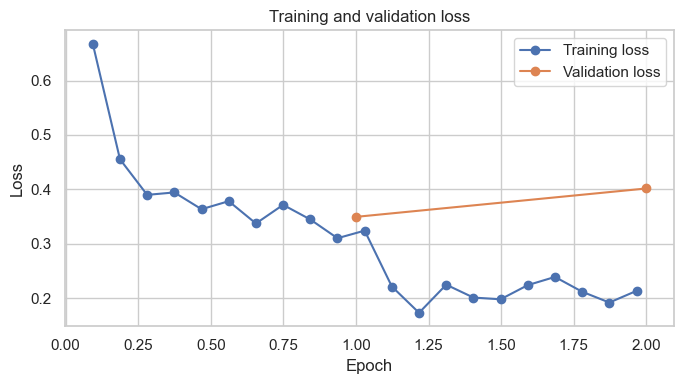

In [46]:
train_logs = log_history_df[log_history_df["loss"].notna()].copy()
eval_logs = log_history_df[log_history_df["eval_loss"].notna()].copy()

plt.figure(figsize=(7, 4))
plt.plot(train_logs["epoch"], train_logs["loss"], marker="o", label="Training loss")
plt.plot(eval_logs["epoch"], eval_logs["eval_loss"], marker="o", label="Validation loss")

plt.title("Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Record the best checkpoint and run summary

Do not treat the run as complete until you can point to the saved checkpoint and the metric used to choose it.

In [47]:
training_run_summary = {
    'output_dir': training_args.output_dir,
    'metric_for_best_model': training_args.metric_for_best_model,
    'best_validation_metric': trainer.state.best_metric,
    'best_model_checkpoint': trainer.state.best_model_checkpoint,
}
training_run_summary

{'output_dir': 'assets/full_tune',
 'metric_for_best_model': 'accuracy',
 'best_validation_metric': 0.8611632270168855,
 'best_model_checkpoint': 'assets/full_tune/checkpoint-1068'}

### Evaluate on validation and test splits

In [48]:
valid_metrics = trainer.evaluate(tokenized_valid)
test_metrics = trainer.evaluate(tokenized_test)

eval_metrics_df = pd.DataFrame([
    {'split': 'validation', **valid_metrics},
    {'split': 'test', **test_metrics},
])
eval_metrics_df

/Users/jacktovey/Library/CloudStorage/OneDrive-UniversityofChichester/COM407-AppliedAI/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


/Users/jacktovey/Library/CloudStorage/OneDrive-UniversityofChichester/COM407-AppliedAI/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


,split,eval_loss,eval_accuracy,eval_macro_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,validation,0.401599,0.861163,0.861104,11.6991,91.118,2.906,2.0
1,test,0.435771,0.854597,0.854593,11.5898,91.977,2.934,2.0


## 7. Full fine-tuning inference and error analysis

Metrics are necessary but insufficient. We also inspect how the fully fine-tuned model behaves on individual examples.

### Generate predictions and confidence scores

We turn logits into predicted labels and confidence scores so we can inspect both accuracy and failure behavior for the fully fine-tuned model.

In [49]:
pred_out = trainer.predict(tokenized_valid)
pred_ids = np.argmax(pred_out.predictions, axis=-1)
probs = torch.softmax(torch.tensor(pred_out.predictions), dim=-1).numpy()
conf = probs.max(axis=1)

results_df = pd.DataFrame({
    'text': valid['text'],
    'true_label': valid['label'],
    'pred_label': pred_ids,
    'confidence': conf,
})
results_df['correct'] = results_df['true_label'] == results_df['pred_label']

results_df.head(10)

/Users/jacktovey/Library/CloudStorage/OneDrive-UniversityofChichester/COM407-AppliedAI/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


,text,true_label,pred_label,confidence,correct
0,compassionately explores the seemingly irrecon...,1,1,0.994071,True
1,the soundtrack alone is worth the price of adm...,1,1,0.880878,True
2,rodriguez does a splendid job of racial profil...,1,1,0.988619,True
3,beneath the film's obvious determination to sh...,1,1,0.990978,True
4,bielinsky is a filmmaker of impressive talent .,1,1,0.994529,True
5,"so beautifully acted and directed , it's clear...",1,1,0.988233,True
6,a visual spectacle full of stunning images and...,1,1,0.996831,True
7,a gentle and engrossing character study .,1,1,0.996438,True
8,"it's enough to watch huppert scheming , with h...",1,1,0.993385,True
9,an engrossing portrait of uncompromising artis...,1,1,0.995142,True


### Confusion matrix (fully fine-tuned model)

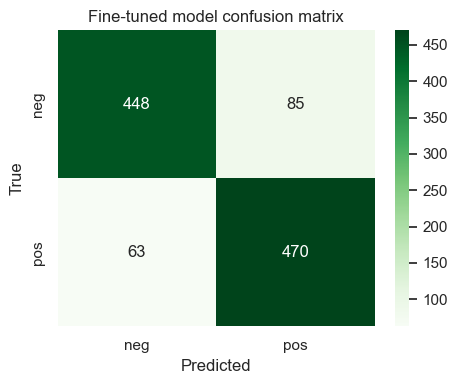

In [50]:
ft_cm = confusion_matrix(results_df['true_label'], results_df['pred_label'])

plt.figure(figsize=(4.8, 4))
sns.heatmap(
    ft_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.title('Fine-tuned model confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

### Top confident errors (fully fine-tuned model)

In [51]:
errors_df = results_df[results_df['true_label'] != results_df['pred_label']].copy()
errors_df = errors_df.sort_values('confidence', ascending=False)
errors_df.head(10)

,text,true_label,pred_label,confidence,correct
632,how much you are moved by the emotional tumult...,0,1,0.993898,False
541,far more enjoyable than its predecessor .,0,1,0.993535,False
705,an uplifting drama . . . what antwone fisher i...,0,1,0.992877,False
951,[allen's] best works understand why snobbery i...,0,1,0.992760,False
942,one of those based-on-truth stories that persu...,0,1,0.992300,False
623,"well-meaning to a fault , antwone fisher manag...",0,1,0.991608,False
948,"a lightweight , uneven action comedy that free...",0,1,0.991315,False
550,"short and sweet , but also more than anything ...",0,1,0.990582,False
695,bravo reveals the true intent of her film by c...,0,1,0.989626,False
1043,wallace directs with such patronising reverenc...,0,1,0.989529,False


## 8. Frozen-head baseline vs full fine-tuning comparison storyboard

Now we answer the real question: did full fine-tuning improve enough to justify its optimization cost?

### Comparison storyboard

Put the frozen-head baseline and the fully fine-tuned model side by side before making a decision.

In [52]:
comparison_storyboard = pd.DataFrame([
    {
        "model": "bert_frozen_head",
        "validation_accuracy": baseline_valid_acc,
        "validation_macro_f1": baseline_valid_f1,
        "trainable_fraction": baseline_summary['parameter_summary']["trainable_fraction"],
        "runtime_note": "encoder frozen, only classifier head updates",
    },
    {
        "model": "bert_full_finetune",
        "validation_accuracy": valid_metrics["eval_accuracy"],
        "validation_macro_f1": valid_metrics["eval_macro_f1"],
        "trainable_fraction": 1,
        "runtime_note": "all weights update",
    },
])

comparison_storyboard

,model,validation_accuracy,validation_macro_f1,trainable_fraction,runtime_note
0,bert_frozen_head,0.759850,0.759796,0.000014,"encoder frozen, only classifier head updates"
1,bert_full_finetune,0.861163,0.861104,1.000000,all weights update


### Improvement over baseline

A delta table makes the trade-off easier to explain in one sentence.
        

In [53]:
baseline_row = comparison_storyboard.loc[
    comparison_storyboard["model"] == "bert_frozen_head"
].iloc[0]

full_row = comparison_storyboard.loc[
    comparison_storyboard["model"] == "bert_full_finetune"
].iloc[0]

delta_comparison = pd.DataFrame([{
    "accuracy_delta": full_row["validation_accuracy"] - baseline_row["validation_accuracy"],
    "macro_f1_delta": full_row["validation_macro_f1"] - baseline_row["validation_macro_f1"],
    "trainable_fraction_delta": full_row["trainable_fraction"] - baseline_row["trainable_fraction"],
}])

delta_comparison

,accuracy_delta,macro_f1_delta,trainable_fraction_delta
0,0.101313,0.101308,0.999986


### Decision statement template

Use this structure:

`Full fine-tuning is / is not justified because ...`

Your answer should mention:
- evidence from the frozen-head baseline,
- evidence from the fully fine-tuned model,
- at least one remaining failure case or limitation,
- the rough compute/runtime trade-off.


### Our Decision

Full fine-tuning is justified because the frozen-head baseline already gave us a useful evidence floor, but the fully fine-tuned model improved on it by a substantial margin. In particular, validation accuracy increased by 0.106 and validation macro F1 increased by 0.106 compared with the frozen-head baseline, which suggests that training only the classifier head was not enough to capture the task as well as possible. This means the pretrained representation was helpful, but allowing the encoder weights to adapt gave a clear additional benefit.


For honesty, we should also note that the fine-tuned model will still make mistakes. For example, it still misclassify reviews with mixed sentiment, subtle wording and sarcasm, even when it is quite confident. So the gain in headline metrics does not mean the model is perfect, and the remaining errors should still be inspected.


The trade-off is compute and runtime. The frozen-head baseline trained only a tiny fraction of the model and was therefore cheaper and faster to optimise, whereas full fine-tuning updated essentially all model weights and so was more computationally expensive. Given the small amount of data compared to trainable parameters it is also prone to overfitting. In this case, however, the performance gain was justified as we had an increase in performance from only two epochs.

### Final Performance Evaluation

After we have decided which model to use we look at it's performance on the test data. This set hasn't been used to compare models so it gives us a good idea of the true generalisation performance of the model.

In [54]:
eval_metrics_df[eval_metrics_df['split'] == 'test']

,split,eval_loss,eval_accuracy,eval_macro_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
1,test,0.435771,0.854597,0.854593,11.5898,91.977,2.934,2.0


## 9. Tuning Failure

If something goes wrong during tuning, we want an idea of how to fix it. Below is some guides to follow:
        



| symptom                          | likely_cause                        | first_fix                             |
|:---------------------------------|:------------------------------------|:--------------------------------------|
| Validation metrics flat          | learning rate too high/too low      | LR sweep around 2e-5                  |
| Training improves but test drops | overfitting                         | fewer epochs, stronger regularization |
| Unexpected label behavior        | label mapping mismatch              | validate id2label/label2id            |
| Out Of Memory errors             | batch too large / sequence too long | reduce batch size or max length       |